# Predicting the Sale Price of Bulldozers using Machine Learning

## 1.Problem definition

> How well can we predict the future sale price of a bulldozer, given its characteristics previous examples of how much similar bulldozers have been sold for?

## 2.Data

The data is downloaded from the Kaggle Bluebook for Bulldozers competition:
https://www.kaggle.com/competitions/bluebook-for-bulldozers/data

**_ Note: Place the files in a `data/` folder at the root of the project. _**

There are 3 main datasets:

- Train.csv is the training set, which contains data through the end of 2011.
- Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
- Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.

## 3.Evaluation

The evaluation metric for this competition is the RMSLE (root mean squared log error) between the actual and predicted auction prices.

## 4.Features

Kaggle provides a data dictionary detailing all of te features of the dataset. You can view this data dictionary on the file:

```
bulldozer-price-prediction/
└── data/
    └── Data Dictionary.xlsx   # This file
```


In [1]:
# Mount Google Drive to access files in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

# Plot appear inside the notebook
%matplotlib inline

In [3]:
# Importing training and validation datasets
# df = pd.read_csv("data/TrainAndValid.csv", low_memory=False)
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/bulldozer/TrainAndValid.csv",
    low_memory=False,
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [4]:
df.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,20136
YearMade,0
MachineHoursCurrentMeter,265194
UsageBand,339028
saledate,0


In [ ]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

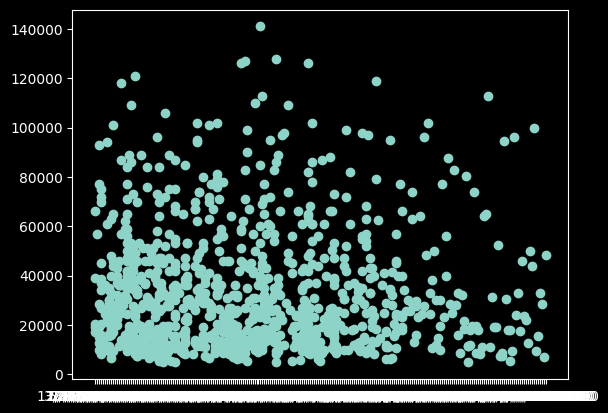

In [6]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])
plt.show()

In [ ]:
df.saledate[:1000]

,saledate
0,11/16/2006 0:00
1,3/26/2004 0:00
2,2/26/2004 0:00
3,5/19/2011 0:00
4,7/23/2009 0:00
...,...
995,7/16/2009 0:00
996,6/14/2007 0:00
997,9/22/2005 0:00
998,7/28/2005 0:00


In [ ]:
df.saledate.dtypes

dtype('O')

<Axes: ylabel='Frequency'>

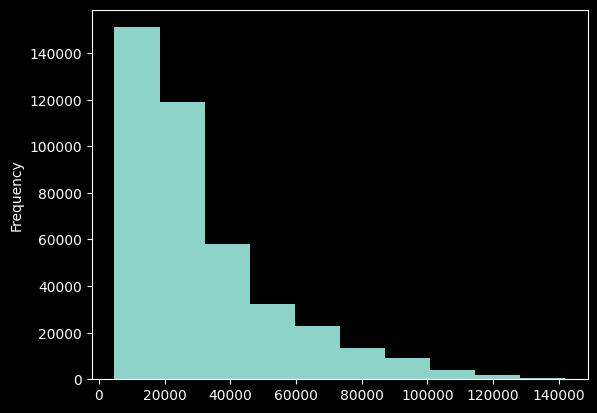

In [9]:
df.SalePrice.plot.hist()

In [10]:
# Parsing dates
# df = pd.read_csv("data/TrainAndValid.csv", low_memory=False, parse_dates=["saledate"])
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/bulldozer/TrainAndValid.csv",
    low_memory=False,
    parse_dates=["saledate"],
)

In [ ]:
df.saledate.dtypes

dtype('<M8[ns]')

In [12]:
df.saledate[:1000]

,saledate
0,2006-11-16
1,2004-03-26
2,2004-02-26
3,2011-05-19
4,2009-07-23
...,...
995,2009-07-16
996,2007-06-14
997,2005-09-22
998,2005-07-28


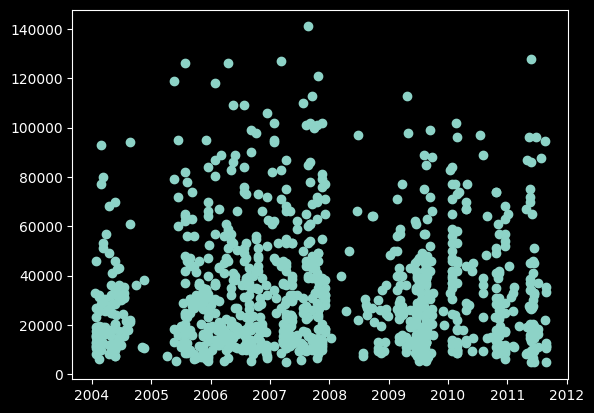

In [13]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])
plt.show()

In [ ]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [16]:
# sorting by saledate in date order
df.sort_values(by=["saledate"], inplace=True)
df.saledate.head(20)

,saledate
205615,1989-01-17
274835,1989-01-31
141296,1989-01-31
212552,1989-01-31
62755,1989-01-31
54653,1989-01-31
81383,1989-01-31
204924,1989-01-31
135376,1989-01-31
113390,1989-01-31


In [17]:
# make a copy
df_temp = df.copy()

In [18]:
df_temp.saledate.head(20)

,saledate
205615,1989-01-17
274835,1989-01-31
141296,1989-01-31
212552,1989-01-31
62755,1989-01-31
54653,1989-01-31
81383,1989-01-31
204924,1989-01-31
135376,1989-01-31
113390,1989-01-31


In [19]:
df_temp["saleYear"] = df_temp["saledate"].dt.year
df_temp["saleMonth"] = df_temp["saledate"].dt.month
df_temp["saleDay"] = df_temp["saledate"].dt.day
df_temp["saleDayOfWeek"] = df_temp["saledate"].dt.day_of_week
df_temp["saleDayOfYear"] = df_temp["saledate"].dt.day_of_year

In [20]:
df_temp.drop("saledate", axis=1, inplace=True)

### Convert string to categories


In [21]:
df_temp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [22]:
str_columns = df_temp.select_dtypes(include=["object", "string"]).columns

for col in str_columns:
    df_temp[col] = df_temp[col].astype("category").cat.as_ordered()

df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [ ]:
df_temp["state"].cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [24]:
df_temp["state"].cat.codes

,0
205615,43
274835,8
141296,8
212552,8
62755,8
...,...
410879,4
412476,4
411927,4
407124,4


### Check missing data


In [25]:
# Export current temp dataframe
# df_temp.to_csv("data/train_tmp.csv", index=False)
df_temp.to_parquet(
    "/content/drive/MyDrive/Colab Notebooks/bulldozer/train_tmp.parquet", index=False
)

# import data tmp
# df_tmp = pd.read_csv("data/train_tmp.csv", low_memory=False)
df_tmp = pd.read_parquet(
    "/content/drive/MyDrive/Colab Notebooks/bulldozer/train_tmp.parquet"
)
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [26]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

#### fill numeric values


In [ ]:
numeric_columns = df_tmp.select_dtypes(include=["number"]).columns

for column in numeric_columns:
    missing_mask = df_tmp[column].isnull()
    if missing_mask.any():
        df_tmp[column + "_is_missing"] = missing_mask
        df_tmp[column] = df_tmp[column].fillna(df_tmp[column].median())

for column in numeric_columns:
    if df_tmp[column].isna().sum():
        print(f"{column} still has missing values")


In [ ]:
df_tmp["auctioneerID_is_missing"].value_counts()

,count
auctioneerID_is_missing,
False,392562
True,20136


#### fill categorical values


In [ ]:
df_temp["UsageBand"].dtype

CategoricalDtype(categories=['High', 'Low', 'Medium'], ordered=True, categories_dtype=object)

In [ ]:
print(df_tmp["UsageBand"].cat.codes)

0        -1
1        -1
2        -1
3        -1
4        -1
         ..
412693   -1
412694   -1
412695   -1
412696   -1
412697   -1
Length: 412698, dtype: int8


In [ ]:
category_columns = df_tmp.select_dtypes(include=["category"]).columns

for column in category_columns:
    missing_mask = df_tmp[column].isnull()
    if missing_mask.any():
        df_tmp[column + "_is_missing"] = missing_mask
    df_tmp[column] = df_tmp[column].cat.codes + 1

for column in category_columns:
    if df_tmp[column].isna().sum():
        print(f"{column} still has missing values")

In [ ]:
df_tmp.select_dtypes(include=["category"])

""
0
1
2
3
4
...
412693
412694
412695
412696


In [33]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 97 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SalesID                              412698 non-null  int64  
 1   SalePrice                            412698 non-null  float64
 2   MachineID                            412698 non-null  int64  
 3   ModelID                              412698 non-null  int64  
 4   datasource                           412698 non-null  int64  
 5   auctioneerID                         412698 non-null  float64
 6   YearMade                             412698 non-null  int64  
 7   MachineHoursCurrentMeter             412698 non-null  float64
 8   UsageBand                            412698 non-null  int8   
 9   fiModelDesc                          412698 non-null  int16  
 10  fiBaseModel                          412698 non-null  int16  
 11  fiSecondaryDe

In [ ]:
df_tmp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
...,...
Backhoe_Mounting_is_missing,0
Blade_Type_is_missing,0
Travel_Controls_is_missing,0
Differential_Type_is_missing,0


# Modeling


In [ ]:
df_tmp["saleYear"].value_counts()

,count
saleYear,
2009,43849
2008,39767
2011,35197
2010,33390
2007,32208
2006,21685
2005,20463
2004,19879
2001,17594


In [37]:
# Split data into training and validation
df_val = df_tmp[df_tmp["saleYear"] == 2012]
df_train = df_tmp[df_tmp["saleYear"] != 2012]
len(df_val), len(df_train)

(11573, 401125)

In [38]:
# Split data into X & y
X_train, y_train = df_train.drop("SalePrice", axis=1), df_train["SalePrice"]
X_val, y_val = df_val.drop("SalePrice", axis=1), df_val["SalePrice"]

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((401125, 96), (401125,), (11573, 96), (11573,))

In [ ]:
# evaluation function
def rmsle(y_test, y_pred):
    """Calculate root mean squared log error between predictions and true labels."""
    return np.sqrt(mean_squared_log_error(y_test, y_pred))


# Evaluate Model
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    scores = {
        "Training  MAE": mean_absolute_error(y_train, train_preds),
        "Valid MAE": mean_absolute_error(y_val, val_preds),
        "Training RMSLE": rmsle(y_train, train_preds),
        "Valid RMSLE": rmsle(y_val, val_preds),
        "Training R^2": r2_score(y_train, train_preds),
        "Valid R^2": r2_score(y_val, val_preds),
    }
    return scores

#### Testing Model


In [40]:
%%time

model = RandomForestRegressor(n_jobs=-1, random_state=42, max_samples=10000)
model.fit(X_train, y_train)

CPU times: user 51.6 s, sys: 289 ms, total: 51.9 s
Wall time: 31 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

In [41]:
show_scores(model)

{'Training  MAE': 5561.513057924589,
 'Valid MAE': 7155.632784930442,
 'Training RMSLE': np.float64(0.2578005599357549),
 'Valid RMSLE': np.float64(0.29223097494391737),
 'Training R^2': 0.860722898583499,
 'Valid R^2': 0.832588403039663}

#### Hyperparameter tuning with RandomizedSearchCV


In [42]:
%%time

model = RandomForestRegressor(n_jobs=-1, random_state=42)

rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "auto"],
    "max_samples": [10000],
}

rs_model = RandomizedSearchCV(
    estimator=model,
    param_distributions=rf_grid,
    n_iter=100,
    cv=5,
    verbose=True,
)

rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

CPU times: user 24min 44s, sys: 42.9 s, total: 25min 27s
Wall time: 16min 40s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=100,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'auto'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [43]:
# the best model
rs_model.best_params_

{'n_estimators': np.int64(30),
 'min_samples_split': np.int64(14),
 'min_samples_leaf': np.int64(3),
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': None}

In [44]:
# Evaluate
show_scores(rs_model)

{'Training  MAE': 6055.515640319444,
 'Valid MAE': 7339.901916596609,
 'Training RMSLE': np.float64(0.27522502112863334),
 'Valid RMSLE': np.float64(0.2983268976555012),
 'Training R^2': 0.8365067095222156,
 'Valid R^2': 0.8260448766827999}

**Best hyperparameter**

In [70]:
%%time

ideal_model = RandomForestRegressor(
    **rs_model.best_params_,
    n_jobs=-1,
    random_state=42
)

ideal_model.fit(X_train, y_train)

CPU times: user 6.19 s, sys: 153 ms, total: 6.35 s
Wall time: 3.4 s


RandomForestRegressor(max_features=0.5, max_samples=10000,
                      min_samples_leaf=np.int64(3),
                      min_samples_split=np.int64(14), n_estimators=np.int64(30),
                      n_jobs=-1, random_state=42)

In [ ]:
show_scores(ideal_model)

{'Training  MAE': 6055.515640319444,
 'Valid MAE': 7339.901916596609,
 'Training RMSLE': np.float64(0.27522502112863334),
 'Valid RMSLE': np.float64(0.2983268976555012),
 'Training R^2': 0.8365067095222156,
 'Valid R^2': 0.8260448766827999}

#### Preprocessing the data

In [60]:
# df_test = pd.read_csv("data/Test.csv", low_memory=False, parse_dates=["saledate"])
df_test = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/bulldozer/Test.csv",
    low_memory=False,
    parse_dates=["saledate"],
)
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [61]:
def preprocess_data(df):
    """Performs transformations on df and return transformed df."""
    df["saleYear"] = df["saledate"].dt.year
    df["saleMonth"] = df["saledate"].dt.month
    df["saleDay"] = df["saledate"].dt.day
    df["saleDayOfWeek"] = df["saledate"].dt.day_of_week
    df["saleDayOfYear"] = df["saledate"].dt.day_of_year
    df.drop("saledate", axis=1, inplace=True)

    str_columns = df.select_dtypes(include=["object", "string"]).columns

    for col in str_columns:
        df[col] = df[col].astype("category").cat.as_ordered()

    numeric_columns = df.select_dtypes(include=["number"]).columns

    for column in numeric_columns:
        missing_mask = df[column].isnull()
        if missing_mask.any():
            df[column + "_is_missing"] = missing_mask
            df[column] = df[column].fillna(df[column].median())

    category_columns = df.select_dtypes(include=["category"]).columns

    for column in category_columns:
        missing_mask = df[column].isnull()
        if missing_mask.any():
            df[column + "_is_missing"] = missing_mask
        df[column] = df[column].cat.codes + 1

    return df


df_test = preprocess_data(df_test)

In [65]:
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True


#### Make predictions

In [76]:
# Check what's different
train_cols = set(X_train.columns)
test_cols  = set(df_test.columns)

print("In X_train but NOT in df_test:", train_cols - test_cols)
print("In df_test but NOT in X_train:", test_cols - train_cols)
print("\nColumn order matches:", list(X_train.columns) == list(df_test.columns))

In X_train but NOT in df_test: set()
In df_test but NOT in X_train: set()

Column order matches: False


In [ ]:
df_test["auctioneerID_is_missing"] = False
df_test = df_test[X_train.columns]
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True


In [78]:
test_preds = ideal_model.predict(df_test)

In [85]:
# Format predictions into the same format as Kaggle is asking for
df_preds = pd.DataFrame()
df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalePrice"] = test_preds
df_preds.head()

,SalesID,SalePrice
0,1227829,18668.936341
1,1227844,20866.735764
2,1227847,53374.237984
3,1227848,62366.906242
4,1227863,39490.073135


In [83]:
# Export predictions to csv
df_preds.to_csv("/content/drive/MyDrive/Colab Notebooks/bulldozer/test_predictions.csv", index=False)

#### Feature Importance

In [86]:
# Find feature importance of our best model
ideal_model.feature_importances_

array([2.84537535e-02, 2.32303931e-02, 3.76786574e-02, 1.97893966e-03,
       3.51339603e-03, 2.08255224e-01, 3.71867392e-03, 1.28051793e-03,
       3.42906968e-02, 4.06898294e-02, 7.32967389e-02, 4.68649517e-03,
       3.47386320e-02, 1.59084093e-01, 4.10921467e-02, 5.97521366e-03,
       2.05212166e-03, 3.04995523e-03, 3.12714583e-03, 4.77599211e-02,
       4.56022696e-04, 7.07854995e-05, 1.80007992e-03, 2.55843810e-04,
       5.52605307e-04, 5.59926887e-04, 1.03797808e-02, 1.59225755e-02,
       2.98945330e-03, 1.95833249e-04, 2.80822297e-03, 1.01115754e-03,
       4.75218833e-03, 2.46009527e-04, 2.79442708e-04, 2.17525230e-02,
       9.21653132e-04, 1.22934428e-02, 1.33453631e-03, 4.00857863e-03,
       2.31145151e-03, 7.11932045e-04, 2.17724409e-03, 8.80756744e-04,
       1.29047044e-03, 6.10217315e-04, 1.61203251e-04, 3.61222652e-03,
       6.40038505e-04, 7.10445583e-05, 1.42583290e-04, 5.79542099e-02,
       3.36475428e-03, 6.31753638e-03, 2.90211032e-03, 8.59265431e-03,
      

In [ ]:
# Helper function for plotting feature importance
def plot_features(columns, importances, n=20):
    df = (
        pd.DataFrame({"features": columns, "feature_importances": importances})
        .sort_values("feature_importances", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots()
    ax.barh(df["features"][:n], df["feature_importances"][:20])
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature importance")
    ax.invert_yaxis()

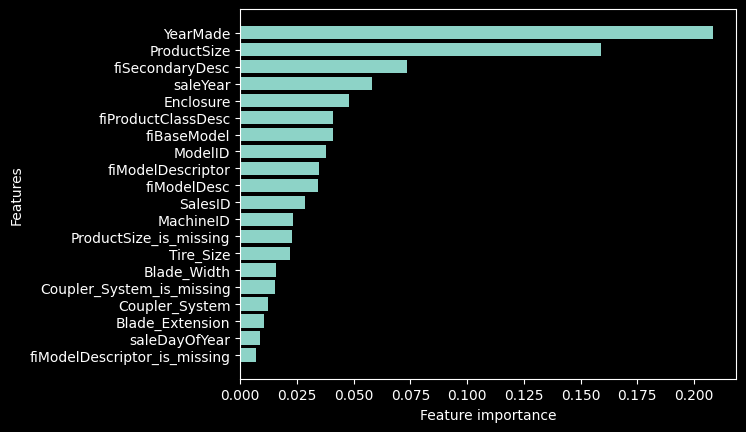

In [88]:
plot_features(X_train.columns, ideal_model.feature_importances_)

In [89]:
df["Enclosure"].value_counts()

,count
Enclosure,
OROPS,177971
EROPS,141769
EROPS w AC,92601
EROPS AC,18
NO ROPS,3
None or Unspecified,2
